In [69]:
#import packages
import numpy as np
import pandas as pd 
#import seaborn as sns   
import matplotlib.pyplot as plt
from pathlib import Path

In [70]:
#Import the data 

"""
#Method 1 : use simple relative path

# Read the CSV with the relative path

df=pd.read_csv('refinitiv_data/nvda_options_20260204_210456.csv')

 # it exists a more robust method.
"""

#Method 2 : use Pathlib

#Get the directory where the notebook is located

notebook_dir = Path.cwd()


# Build the path to the CSV file
csv_file = notebook_dir / 'refinitiv_data' / 'nvda_options_20260204_210456.csv'

df=pd.read_csv(csv_file)



df.head()

,Instrument,Implied Volatility,Strike Price,Expiry Date,BID,ASK,CF_LAST,PUTCALLIND
0,NVDAB202619000.U,40.4573,190.0,2026-02-20,1.55,1.58,1.55,CALL
1,NVDAB202618000.U,43.4314,180.0,2026-02-20,4.55,4.60,4.55,CALL
2,NVDAN202618000.U,43.2729,180.0,2026-02-20,8.60,8.70,8.49,PUT
3,NVDAB202618500.U,41.8484,185.0,2026-02-20,2.73,2.76,2.75,CALL
4,NVDAC202620000.U,45.9441,200.0,2026-03-20,3.75,3.85,3.80,CALL


In [71]:
#Renaming the columns in a more convenient way
df= df.copy()
df.columns = ['instrument', 'iv', 'srike', 'expiry', 'bid', 'ask', 'last', 'type']

In [72]:
df.head()

,instrument,iv,srike,expiry,bid,ask,last,type
0,NVDAB202619000.U,40.4573,190.0,2026-02-20,1.55,1.58,1.55,CALL
1,NVDAB202618000.U,43.4314,180.0,2026-02-20,4.55,4.60,4.55,CALL
2,NVDAN202618000.U,43.2729,180.0,2026-02-20,8.60,8.70,8.49,PUT
3,NVDAB202618500.U,41.8484,185.0,2026-02-20,2.73,2.76,2.75,CALL
4,NVDAC202620000.U,45.9441,200.0,2026-03-20,3.75,3.85,3.80,CALL


In [73]:
df.describe()

#the mean is very high, looking at the data there is some huge values (>700 !)
#let's filter those values

,iv,srike,bid,ask,last
count,1000.000000,1000.00000,991.000000,991.000000,991.000000
mean,80.455764,147.55300,40.140373,40.754753,40.655237
std,82.023650,80.63104,47.389229,48.455843,48.629794
min,38.617900,0.50000,0.000000,0.010000,0.010000
25%,46.179675,95.00000,5.550000,5.625000,5.490000
50%,48.967100,165.00000,24.550000,24.650000,24.710000
75%,80.755175,195.00000,51.425000,51.975000,51.025000
max,939.225100,380.00000,203.550000,205.350000,199.650000


In [74]:
#Implementing bid ask spread
#Quantify liquidity on the df

# CORRECT formula
df["bid_ask_spread"] = (df["ask"] - df["bid"]) / (0.5 * (df["bid"] + df["ask"]))


df.head()

,instrument,iv,srike,expiry,bid,ask,last,type,bid_ask_spread
0,NVDAB202619000.U,40.4573,190.0,2026-02-20,1.55,1.58,1.55,CALL,0.019169
1,NVDAB202618000.U,43.4314,180.0,2026-02-20,4.55,4.60,4.55,CALL,0.010929
2,NVDAN202618000.U,43.2729,180.0,2026-02-20,8.60,8.70,8.49,PUT,0.011561
3,NVDAB202618500.U,41.8484,185.0,2026-02-20,2.73,2.76,2.75,CALL,0.010929
4,NVDAC202620000.U,45.9441,200.0,2026-03-20,3.75,3.85,3.80,CALL,0.026316


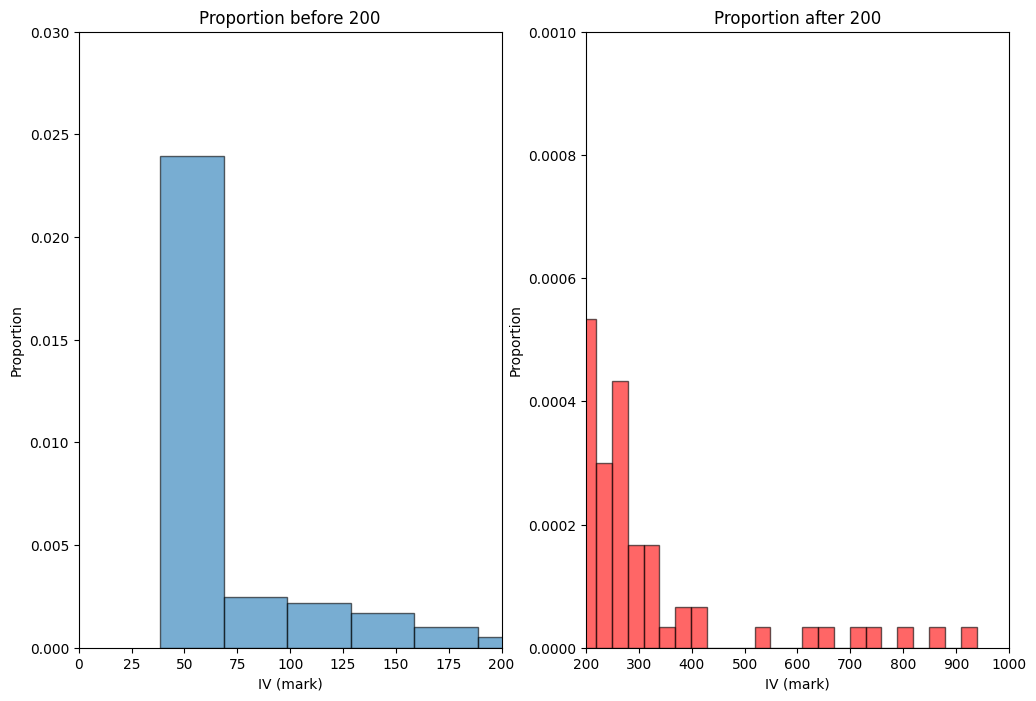

In [96]:
fig, axes = plt.subplots(1,2,figsize=(12,8))
axes[0].hist(df["iv"], bins=30, density=True, alpha=0.6, edgecolor='black')
axes[0].set_xlim(0,200)
axes[0].set_ylim(0, 0.03)
axes[0].set_xlabel("IV (mark)")
axes[0].set_ylabel("Proportion")
axes[0].set_title("Proportion before 200")

axes[1].hist(df["iv"], bins=30, density=True, color = "red", alpha=0.6, edgecolor='black')
axes[1].set_xlim(200,1000)
axes[1].set_ylim(0, 0.001)
axes[1].set_xlabel("IV (mark)")
axes[1].set_ylabel("Proportion")
axes[1].set_title("Proportion after 200")

plt.show()

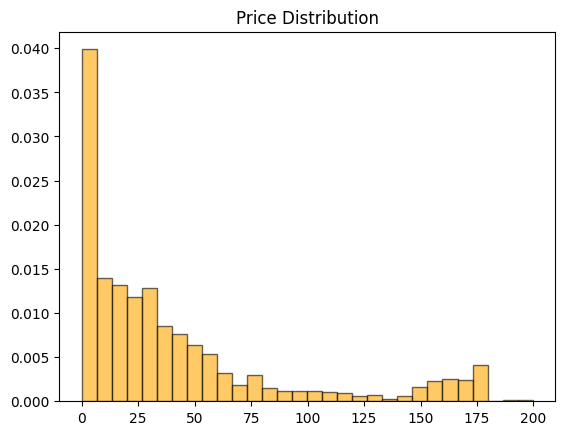

In [76]:
plt.hist(df["last"], bins=30, color="orange", density=True, alpha=0.6, edgecolor='black')
plt.title("Price Distribution")
plt.show()

In [83]:
df_sorted=df[df["iv"]<=100].copy()
df_sorted

,instrument,iv,srike,expiry,bid,ask,last,type,bid_ask_spread
0,NVDAB202619000.U,40.4573,190.0,2026-02-20,1.55,1.58,1.55,CALL,0.019169
1,NVDAB202618000.U,43.4314,180.0,2026-02-20,4.55,4.60,4.55,CALL,0.010929
2,NVDAN202618000.U,43.2729,180.0,2026-02-20,8.60,8.70,8.49,PUT,0.011561
3,NVDAB202618500.U,41.8484,185.0,2026-02-20,2.73,2.76,2.75,CALL,0.010929
4,NVDAC202620000.U,45.9441,200.0,2026-03-20,3.75,3.85,3.80,CALL,0.026316
...,...,...,...,...,...,...,...,...,...
993,NVDAL172712000.U,53.0541,120.0,2027-12-17,78.55,79.50,78.10,CALL,0.012022
994,NVDAX172707000.U,55.0331,70.0,2027-12-17,3.35,3.50,3.50,PUT,0.043796
995,NVDAE152608000.U,75.7454,80.0,2026-05-15,96.30,97.35,101.48,CALL,0.010844
997,NVDAF182638000.U,49.1091,380.0,2026-06-18,0.16,0.17,0.16,CALL,0.060606


In [78]:
df_sorted.describe()

,iv,srike,bid,ask,last,bid_ask_spread
count,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000
mean,51.678402,173.824937,29.242166,29.531826,29.280076,0.068251
std,11.453688,57.464015,27.802317,28.185788,27.829025,0.278170
min,38.617900,15.000000,0.000000,0.010000,0.010000,0.001436
25%,45.743100,145.000000,7.787500,7.887500,7.950000,0.006381
50%,47.710750,176.500000,23.350000,23.500000,23.460000,0.009123
75%,51.209875,200.000000,42.537500,42.750000,42.440000,0.014898
max,98.886000,380.000000,193.250000,195.650000,189.680000,2.000000


In [79]:
threshold = 100
df[df["iv"] > threshold ]
#ok we see that they are a lot of options with no bid and no ask => totally illiquid. 

,instrument,iv,srike,expiry,bid,ask,last,type,bid_ask_spread
136,NVDAA302609000.U,851.3641,90.0,2026-01-30,NaN,NaN,NaN,CALL,NaN
144,NVDAA302611000.U,650.8231,110.0,2026-01-30,NaN,NaN,NaN,CALL,NaN
145,NVDAM302607500.U,707.8410,75.0,2026-01-30,NaN,NaN,NaN,PUT,NaN
154,NVDAM302609500.U,538.6125,95.0,2026-01-30,NaN,NaN,NaN,PUT,NaN
158,NVDAA302609500.U,814.6601,95.0,2026-01-30,NaN,NaN,NaN,CALL,NaN
...,...,...,...,...,...,...,...,...,...
985,NVDAF182603300.U,133.0240,33.0,2026-06-18,140.90,145.65,148.13,CALL,0.033153
989,NVDAQ152601500.U,154.1118,15.0,2026-05-15,0.00,0.02,0.02,PUT,2.000000
990,NVDAF182602800.U,138.9314,28.0,2026-06-18,146.15,150.25,152.95,CALL,0.027665
996,NVDAR182603700.U,100.3343,37.0,2026-06-18,0.04,0.06,0.06,PUT,0.400000


In [84]:
df_sorted.dropna(inplace=True)
df_sorted.describe()

,iv,srike,bid,ask,last,bid_ask_spread
count,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000
mean,51.678402,173.824937,29.242166,29.531826,29.280076,0.068251
std,11.453688,57.464015,27.802317,28.185788,27.829025,0.278170
min,38.617900,15.000000,0.000000,0.010000,0.010000,0.001436
25%,45.743100,145.000000,7.787500,7.887500,7.950000,0.006381
50%,47.710750,176.500000,23.350000,23.500000,23.460000,0.009123
75%,51.209875,200.000000,42.537500,42.750000,42.440000,0.014898
max,98.886000,380.000000,193.250000,195.650000,189.680000,2.000000


In [94]:
liq_threshold=0.3
#retaining only options which bid_ask_spread <= 30 %



df_sorted = df_sorted[df_sorted["bid_ask_spread"] <= liq_threshold].copy()
df_sorted.describe()

,iv,srike,bid,ask,last,bid_ask_spread
count,757.000000,757.000000,757.000000,757.000000,757.000000,757.000000
mean,50.343967,174.490753,30.670079,30.972431,30.708983,0.015985
std,9.395894,49.625641,27.694529,28.084251,27.721551,0.028283
min,38.617900,25.000000,0.030000,0.040000,0.030000,0.001436
25%,45.657600,146.000000,10.000000,10.150000,10.150000,0.006231
50%,47.493400,177.000000,25.050000,25.200000,25.150000,0.008873
75%,50.340400,200.000000,44.000000,44.450000,44.130000,0.013423
max,98.886000,380.000000,193.250000,195.650000,189.680000,0.285714


- No real effect on the data even with 0.3 
- Our 873 options already sorted with normal iv and removing pure illiquid options have a threshold <= 0.3